## MSE 546 Project Proposal Code

In [2]:
import numpy as np
import plotly.express as px
import seaborn as sns
import random
import io
import pandas as pd

from matplotlib import pyplot as plt
from google.colab import files
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

### Exploratory Data Analysis

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Load data in dataframe (On Google Collab)
uploaded = files.upload()

train_student_data = pd.read_csv("train.csv")
test_student_data = pd.read_csv("test.csv")

train_student_data.head()

Saving test.csv to test.csv
Saving train.csv to train.csv


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [7]:
train_student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [8]:
# Drop ID column (redundant)
train_student_data = train_student_data.drop(columns=["id"])
test_student_data = test_student_data.drop(columns=["id"])

# Explore all unique values for categorical features

print("Unique Gender:", train_student_data["gender"].unique())
print("Unique Course:", train_student_data["course"].unique())
print("Unique Internet Access:", train_student_data["internet_access"].unique())
print("Sleep Quality:", train_student_data["sleep_quality"].unique())
print("Study Method:", train_student_data["study_method"].unique())
print("Facility Rating:", train_student_data["facility_rating"].unique())
print("Exam Difficulty:", train_student_data["exam_difficulty"].unique())


Unique Gender: ['female' 'other' 'male']
Unique Course: ['b.sc' 'diploma' 'bca' 'b.com' 'ba' 'bba' 'b.tech']
Unique Internet Access: ['no' 'yes']
Sleep Quality: ['average' 'poor' 'good']
Study Method: ['online videos' 'self-study' 'coaching' 'group study' 'mixed']
Facility Rating: ['low' 'medium' 'high']
Exam Difficulty: ['easy' 'moderate' 'hard']


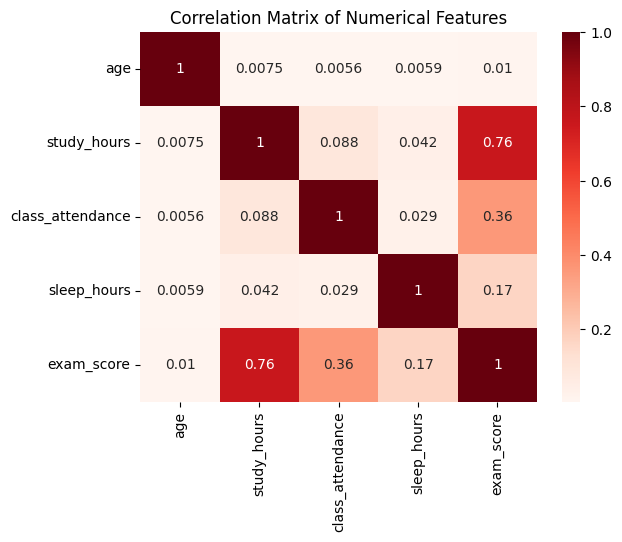

In [9]:
# Analyze correlation between numerical features
numerical_features = ["age", "study_hours", "class_attendance", "sleep_hours", "exam_score"]
corr_matrix = train_student_data[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap="Reds")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [10]:
# Make Internet Access Binary (Yes = 1, No =0)
train_student_data["internet_access"] = train_student_data["internet_access"].map({"yes": 1, "no": 0})
test_student_data["internet_access"] = test_student_data["internet_access"].map({"yes": 1, "no": 0})

# One Hot Encode remaining categorical features

categorical_features = ["gender","course","sleep_quality","study_method","facility_rating","exam_difficulty"]
one_hot_data = train_student_data[categorical_features]

encoder = OneHotEncoder(drop="first", sparse_output=False) # Avoid multicollinearity

one_hot_encoded = encoder.fit_transform(one_hot_data)
one_hot_names = encoder.get_feature_names_out(categorical_features)

# Replace existing categorical rows
train_student_data = pd.concat(
    [train_student_data.drop(columns=categorical_features), pd.DataFrame(one_hot_encoded, columns=one_hot_names)],
    axis=1
)

test_student_data = pd.concat(
    [test_student_data.drop(columns=categorical_features), pd.DataFrame(encoder.transform(test_student_data[categorical_features]), columns=one_hot_names)],
    axis=1
)

# View all hot encoded categorical features (for viewing)
print(one_hot_names)

['gender_male' 'gender_other' 'course_b.sc' 'course_b.tech' 'course_ba'
 'course_bba' 'course_bca' 'course_diploma' 'sleep_quality_good'
 'sleep_quality_poor' 'study_method_group study' 'study_method_mixed'
 'study_method_online videos' 'study_method_self-study'
 'facility_rating_low' 'facility_rating_medium' 'exam_difficulty_hard'
 'exam_difficulty_moderate']


In [11]:
# Print new dataframe
train_student_data.head()

,age,study_hours,class_attendance,internet_access,sleep_hours,exam_score,gender_male,gender_other,course_b.sc,course_b.tech,...,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium,exam_difficulty_hard,exam_difficulty_moderate
0,21,7.91,98.8,0,4.9,78.3,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,18,4.95,94.8,1,4.7,46.7,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2,20,4.68,92.6,1,5.8,99.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,19,2.00,49.5,1,8.3,63.9,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,23,7.65,86.9,1,9.6,100.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### 1. Linear Regression: Baseline Case

In [12]:
# Remove target feature from feature list
target = "exam_score"

features = list(train_student_data.columns)
features.remove(target)

X_train = train_student_data[features]
y_train = train_student_data[target]

X_test = test_student_data[features]

# Train on linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Print Linear Regression Coefficients
print("Intercept:", lin_reg.intercept_)
pd.DataFrame(lin_reg.coef_, features, columns = ["Coefficient"])

Intercept: 17.72824650268941


,Coefficient
age,-0.013699
study_hours,5.676465
class_attendance,0.312254
internet_access,0.023373
sleep_hours,1.321698
gender_male,-0.105472
gender_other,0.190581
course_b.sc,-0.177876
course_b.tech,0.167018
course_ba,-0.033243


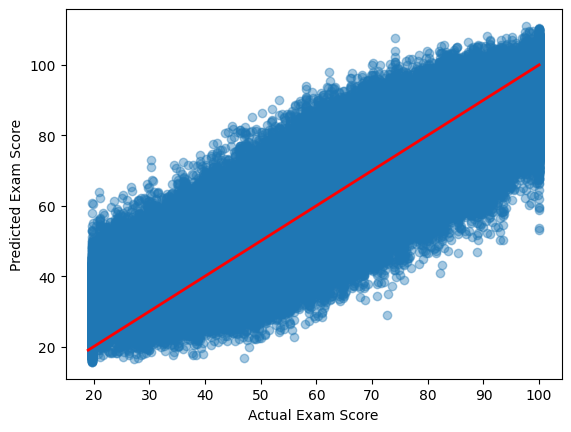

In [18]:
# Evaluate model performance (training data)
y_train_pred = lin_reg.predict(X_train)

# Graph actual vs predicted in scatter plot for training data
plt.scatter(y_train, y_train_pred, alpha=0.4)
plt.plot([19, 100], [19, 100], 'r', lw=2)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.show()

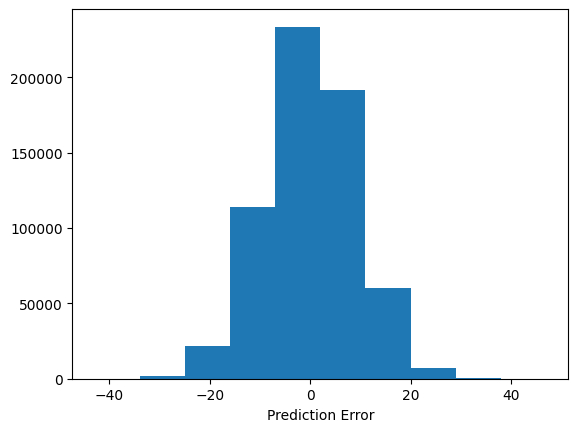

In [19]:
plt.hist(y_train - y_train_pred)
plt.xlabel("Prediction Error")
plt.show()

In [20]:
# Regression Model Evaluation Metrics (training data)

res_metrics = pd.DataFrame({
  "MAE": [metrics.mean_absolute_error(y_train, y_train_pred)],
  "MSE": [metrics.mean_squared_error(y_train, y_train_pred)],
  "RMSE": [np.sqrt(metrics.mean_squared_error(y_train, y_train_pred))],
  "R2": [metrics.r2_score(y_train, y_train_pred)]
})

pd.set_option("float_format", "{:f}".format)
res_metrics

,MAE,MSE,RMSE,R2
0,7.100962,79.110443,8.894405,0.778927


### 2. Random Forest Solution

In [13]:
# Train Random Forest on the same feature matrix
rf_reg = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train, y_train)

# Evaluate model performance (training data)
y_train_pred_rf = rf_reg.predict(X_train)

# Show top feature importances (Random Forest equivalent of coefficients)
pd.DataFrame({
    "Feature": features,
    "Importance": rf_reg.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

,Feature,Importance
1,study_hours,0.644131
2,class_attendance,0.138468
4,sleep_hours,0.051592
14,sleep_quality_poor,0.024918
0,age,0.022416
19,facility_rating_low,0.019753
13,sleep_quality_good,0.014850
18,study_method_self-study,0.010164
17,study_method_online videos,0.009009
15,study_method_group study,0.008452


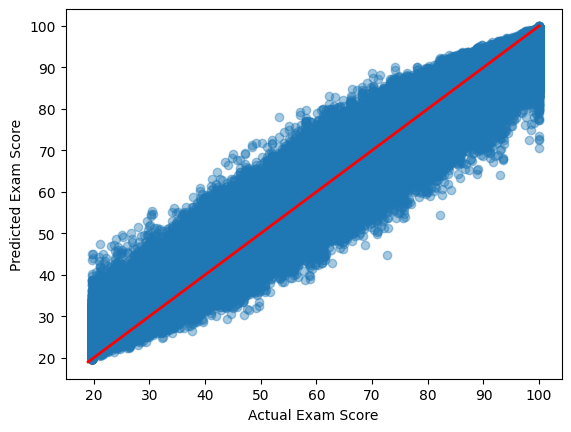

In [14]:
# Graph actual vs predicted in scatter plot for training data
plt.scatter(y_train, y_train_pred_rf, alpha=0.4)
plt.plot([19, 100], [19, 100], 'r', lw=2)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.show()


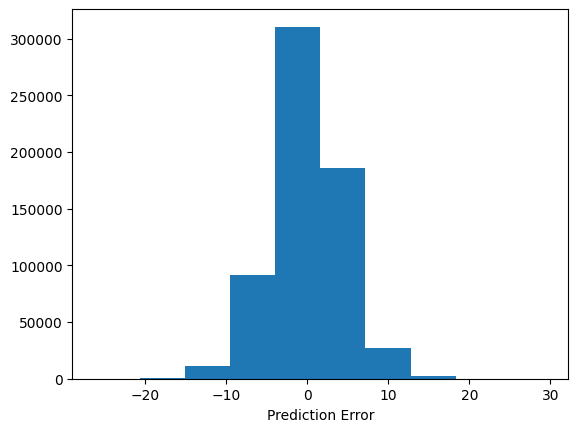

In [15]:
plt.hist(y_train - y_train_pred_rf)
plt.xlabel("Prediction Error")
plt.show()

In [16]:
# Regression Model Evaluation Metrics (training data)
rf_metrics = pd.DataFrame({
  "MAE": [metrics.mean_absolute_error(y_train, y_train_pred_rf)],
  "MSE": [metrics.mean_squared_error(y_train, y_train_pred_rf)],
  "RMSE": [np.sqrt(metrics.mean_squared_error(y_train, y_train_pred_rf))],
  "R2": [metrics.r2_score(y_train, y_train_pred_rf)]
})

pd.set_option("float_format", "{:f}".format)
rf_metrics

,MAE,MSE,RMSE,R2
0,3.345756,18.865886,4.343488,0.947280


### 3. Neural Network Solution

In [21]:
# Build and train neural network
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

nn_sgd_scaler = StandardScaler()
X_train_nn_sgd = nn_sgd_scaler.fit_transform(X_train)

nn_sgd_best = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="sgd",
    alpha=1e-4,
    learning_rate_init=1e-3,
    learning_rate="constant",
    momentum=0.9,
    nesterovs_momentum=True,
    batch_size=256,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
)

nn_sgd_best.fit(X_train_nn_sgd, y_train)

# Evaluate model performance (training data)
y_train_pred_nn_sgd = nn_sgd_best.predict(X_train_nn_sgd)

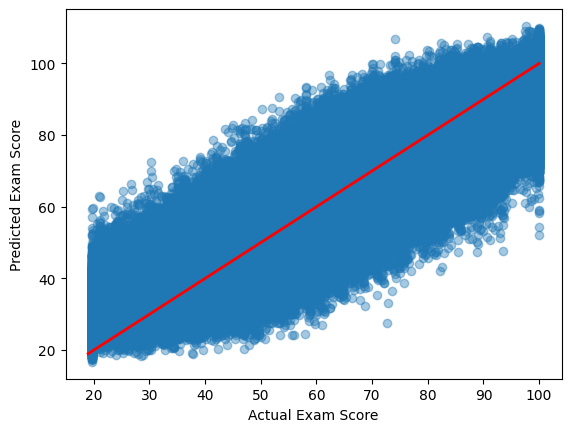

In [22]:
# Graph actual vs predicted in scatter plot for training data
plt.scatter(y_train, y_train_pred_nn_sgd, alpha=0.4)
plt.plot([19, 100], [19, 100], 'r', lw=2)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.show()

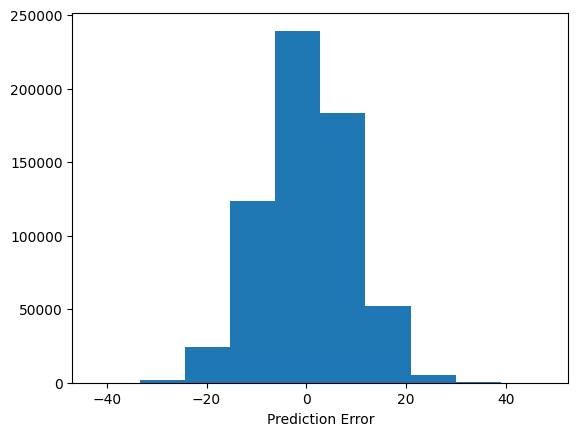

In [23]:
plt.hist(y_train - y_train_pred_nn_sgd)
plt.xlabel("Prediction Error")
plt.show()

In [24]:
# Regression Model Evaluation Metrics (training data)
nn_sgd_metrics = pd.DataFrame({
  "MAE": [metrics.mean_absolute_error(y_train, y_train_pred_nn_sgd)],
  "MSE": [metrics.mean_squared_error(y_train, y_train_pred_nn_sgd)],
  "RMSE": [np.sqrt(metrics.mean_squared_error(y_train, y_train_pred_nn_sgd))],
  "R2": [metrics.r2_score(y_train, y_train_pred_nn_sgd)]
})

pd.set_option("float_format", "{:f}".format)
nn_sgd_metrics

,MAE,MSE,RMSE,R2
0,7.079680,78.607756,8.866102,0.780332


### 4. Build Submission Function to Evaluate Test Error

In [17]:
# Generate test predicitions
def test_prediction(coefficients, intercept):

    coefficients = np.array(coefficients) # Convert to numpy array for dot product
    exam_score = intercept + test_student_data.values.dot(coefficients)

    df_test_pred = pd.DataFrame({
        "id": id_data,
        "exam_score": exam_score
    })
    return df_test_pred

# Generic prediction helper for non-linear models without coefficients/intercept
def test_prediction_model(model):

    exam_score = model.predict(X_test)

    df_test_pred = pd.DataFrame({
        "id": id_data,
        "exam_score": exam_score
    })
    return df_test_pred

# Generate test predictions for scaled non-linear models
def test_prediction_scaled_model(model, scaler):

    X_test_scaled = scaler.transform(X_test)
    exam_score = np.clip(model.predict(X_test_scaled), 0, 100)

    df_test_pred = pd.DataFrame({
        "id": test_ids,
        "exam_score": exam_score
    })
    return df_test_pred

In [18]:
# Generate submission CSVs
df_lr = test_prediction(lin_reg.coef_, lin_reg.intercept_)
df_lr.to_csv("linear_regression_submission.csv", index=False)

df_rf = test_prediction_model(rf_reg)
df_rf.to_csv("random_forest_submission.csv", index=False)

df_ga = test_prediction(ga_model.coef_, ga_model.intercept_)
df_ga.to_csv("genetic_algorithm_submission.csv", index=False)

df_nn_sgd = test_prediction_scaled_model(nn_sgd_best, nn_sgd_scaler)
df_nn_sgd.to_csv("neural_network_submission.csv", index=False)

NameError: name 'id_data' is not defined